# 01 — Boolean QOS 的核心机制

这一章完全离线，只用 NumPy 验证论文最基本的 Quantum Oracle
Sketching。

目标 Boolean phase oracle：

$$
O_f=\sum_{x=0}^{N-1}(-1)^{f(x)}|x\rangle\langle x|.
$$

每个均匀经典样本 $(x_i,y_i)$，其中 $y_i=f(x_i)$，贡献：

$$
V_i=\exp\left(
  i\frac{\pi N}{M}y_i|x_i\rangle\langle x_i|
\right).
$$

如果地址 $x$ 在 $M$ 个样本中出现 $C_x$ 次，它获得的总相位为：

$$
\widetilde\phi_x=\frac{\pi N}{M}C_x f(x).
$$

因为 $C_x$ 通常接近 $M/N$，所以
$\widetilde\phi_x\approx\pi f(x)$。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260728
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=4, suppress=True)

In [2]:
def make_boolean_function(n_address, kind="parity", *, marked=None, seed=0):
    if n_address < 1:
        raise ValueError("n_address must be at least 1.")

    n_states = 2**n_address
    addresses = np.arange(n_states, dtype=int)

    if kind == "parity":
        values = np.array([x.bit_count() % 2 for x in addresses], dtype=np.int8)
    elif kind == "majority":
        threshold = (n_address + 1) // 2
        values = np.array(
            [x.bit_count() >= threshold for x in addresses], dtype=np.int8
        )
    elif kind == "marked":
        marked = {n_states - 1} if marked is None else set(marked)
        if not marked.issubset(set(addresses)):
            raise ValueError("marked contains an address outside the register.")
        values = np.array([x in marked for x in addresses], dtype=np.int8)
    elif kind == "random":
        local_rng = np.random.default_rng(seed)
        values = local_rng.integers(0, 2, size=n_states, dtype=np.int8)
    else:
        raise ValueError(f"Unknown Boolean function kind: {kind}")

    return values


def draw_uniform_stream(f_values, num_samples, rng):
    if num_samples < 1:
        raise ValueError("num_samples must be positive.")
    addresses = rng.integers(0, len(f_values), size=num_samples)
    labels = f_values[addresses]
    return addresses, labels


def qos_phase_angles(f_values, addresses, labels):
    addresses = np.asarray(addresses, dtype=int)
    labels = np.asarray(labels, dtype=int)

    if len(addresses) == 0 or len(addresses) != len(labels):
        raise ValueError("addresses and labels must have the same nonzero length.")
    if np.any((addresses < 0) | (addresses >= len(f_values))):
        raise ValueError("stream contains an invalid address.")
    if np.any((labels != 0) & (labels != 1)):
        raise ValueError("Boolean labels must be 0 or 1.")
    if np.any(labels != f_values[addresses]):
        raise ValueError("labels are inconsistent with f(address).")

    theta = np.pi * len(f_values) / len(addresses)
    phase = np.zeros(len(f_values), dtype=float)
    np.add.at(phase, addresses, theta * labels)
    return phase


def plus_input_fidelity(f_values, sketch_phase):
    target_phase = np.pi * np.asarray(f_values)
    relative_phase = sketch_phase - target_phase
    overlap = np.mean(np.exp(1j * relative_phase))
    return float(abs(overlap) ** 2)


def run_one_stream(f_values, num_samples, rng):
    addresses, labels = draw_uniform_stream(f_values, num_samples, rng)
    phase = qos_phase_angles(f_values, addresses, labels)
    fidelity = plus_input_fidelity(f_values, phase)
    return fidelity, addresses, labels, phase

## 单个经典样本对应的量子线路图

以两个地址 qubits、地址 $x=1$（二进制 `01`）为例。`address_0` 是最低有效位：

1. 地址中为 0 的 `address_1` 先经过 X mask；
2. CCX 检查两个地址位是否同时为 1，并把结果写进 `work`；
3. `work` 上的 $P(\theta)$ 只给匹配分支增加相位；
4. 第二个 CCX 反计算工作位；
5. 最后的 X 撤销 mask。

工作位最终回到 $|0\rangle$，所以它只是一张临时“是否匹配”的草稿纸。

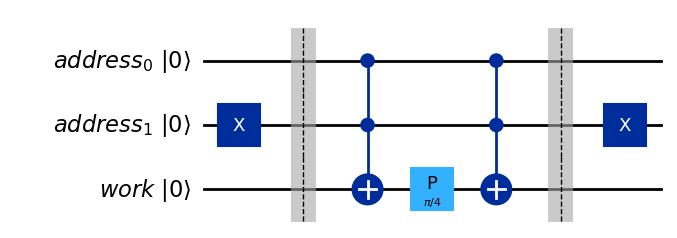

In [3]:
from pathlib import Path

from qiskit import QuantumCircuit, QuantumRegister


def build_projector_phase_visual(n_address, address_value, theta):
    address_register = QuantumRegister(n_address, "address")
    work_register = QuantumRegister(1, "work")
    circuit = QuantumCircuit(address_register, work_register)

    zero_bits = [
        bit
        for bit in range(n_address)
        if ((address_value >> bit) & 1) == 0
    ]
    for bit in zero_bits:
        circuit.x(address_register[bit])

    circuit.barrier()
    if n_address == 1:
        circuit.cx(address_register[0], work_register[0])
    elif n_address == 2:
        circuit.ccx(
            address_register[0],
            address_register[1],
            work_register[0],
        )
    else:
        circuit.mcx(list(address_register), work_register[0])

    circuit.p(theta, work_register[0])

    if n_address == 1:
        circuit.cx(address_register[0], work_register[0])
    elif n_address == 2:
        circuit.ccx(
            address_register[0],
            address_register[1],
            work_register[0],
        )
    else:
        circuit.mcx(list(address_register), work_register[0])

    circuit.barrier()
    for bit in reversed(zero_bits):
        circuit.x(address_register[bit])

    return circuit


sample_update_circuit = build_projector_phase_visual(
    n_address=2,
    address_value=1,
    theta=np.pi / 4,
)

asset_dir = Path("../assets/circuits")
asset_dir.mkdir(parents=True, exist_ok=True)
sample_update_figure = sample_update_circuit.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
sample_update_figure.savefig(
    asset_dir / "projector-phase-update.png",
    dpi=180,
    bbox_inches="tight",
)
sample_update_figure

## 先看一个 $n=2$、$N=4$ 的具体数据流

表格中 `count` 是地址出现次数，`sketch_phase/pi` 应逐渐接近
`target_phase/pi = f(x)`。

In [4]:
n_address = 2
f_values = make_boolean_function(n_address, "parity")
num_samples = 32

fidelity, addresses, labels, sketch_phase = run_one_stream(
    f_values, num_samples, rng
)
counts = np.bincount(addresses, minlength=len(f_values))

phase_table = pd.DataFrame(
    {
        "address": np.arange(len(f_values)),
        "f(x)": f_values,
        "count": counts,
        "expected count": num_samples / len(f_values),
        "sketch_phase/pi": sketch_phase / np.pi,
        "target_phase/pi": f_values,
    }
)

display(phase_table)
print(f"F_+ = {fidelity:.6f}")
print(f"epsilon_+ = 1 - F_+ = {1 - fidelity:.6f}")

,address,f(x),count,expected count,sketch_phase/pi,target_phase/pi
0,0,0,8,8.0,0.000,0
1,1,1,3,8.0,0.375,1
2,2,1,10,8.0,1.250,1
3,3,0,11,8.0,0.000,0


F_+ = 0.340621
epsilon_+ = 1 - F_+ = 0.659379


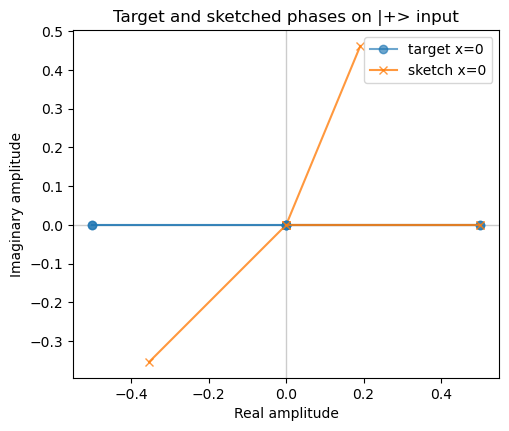

In [5]:
target_state = np.exp(1j * np.pi * f_values) / np.sqrt(len(f_values))
sketch_state = np.exp(1j * sketch_phase) / np.sqrt(len(f_values))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)
for x, (target_amp, sketch_amp) in enumerate(zip(target_state, sketch_state)):
    ax.plot(
        [0, target_amp.real],
        [0, target_amp.imag],
        marker="o",
        label=f"target x={x}" if x == 0 else None,
        color="tab:blue",
        alpha=0.65,
    )
    ax.plot(
        [0, sketch_amp.real],
        [0, sketch_amp.imag],
        marker="x",
        label=f"sketch x={x}" if x == 0 else None,
        color="tab:orange",
        alpha=0.8,
    )
ax.set(
    xlabel="Real amplitude",
    ylabel="Imaginary amplitude",
    title="Target and sketched phases on |+> input",
    aspect="equal",
)
ax.legend()
plt.show()

## 扫描经典数据样本数 $M$

对每个 $M$ 生成 `R_STREAMS` 条独立数据流。误差条反映
**between-stream variance**，还没有加入有限 shots。

,M_data,R_streams,mean_infidelity,ci95,median_infidelity
0,8,300,0.739792,0.027355,0.750000
1,16,300,0.637500,0.022232,0.687500
2,32,300,0.497921,0.023602,0.510723
3,64,300,0.353934,0.021272,0.339524
4,128,300,0.196202,0.014024,0.169113
5,256,300,0.106866,0.008310,0.092419
6,512,300,0.058455,0.004450,0.052213
7,1024,300,0.031691,0.002550,0.026476


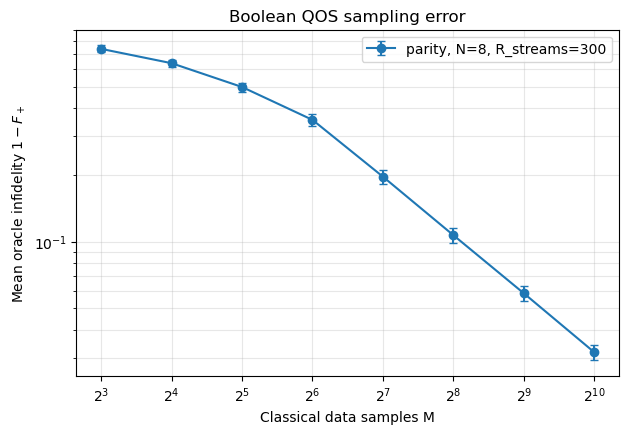

In [6]:
def sweep_data_samples(f_values, sample_sizes, num_streams, seed):
    local_rng = np.random.default_rng(seed)
    rows = []

    for num_samples in sample_sizes:
        fidelities = np.array(
            [
                run_one_stream(f_values, num_samples, local_rng)[0]
                for _ in range(num_streams)
            ]
        )
        infidelities = 1.0 - fidelities
        sem = infidelities.std(ddof=1) / np.sqrt(num_streams)
        rows.append(
            {
                "M_data": num_samples,
                "R_streams": num_streams,
                "mean_infidelity": infidelities.mean(),
                "ci95": 1.96 * sem,
                "median_infidelity": np.median(infidelities),
            }
        )

    return pd.DataFrame(rows)


n_address = 3
f_values = make_boolean_function(n_address, "parity")
n_states = len(f_values)
sample_sizes = n_states * 2 ** np.arange(0, 8)
R_STREAMS = 300

sweep = sweep_data_samples(
    f_values, sample_sizes, R_STREAMS, seed=SEED + 1
)
display(sweep)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    sweep["M_data"],
    sweep["mean_infidelity"],
    yerr=sweep["ci95"],
    marker="o",
    capsize=3,
    label=f"parity, N={n_states}, R_streams={R_STREAMS}",
)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set(
    xlabel="Classical data samples M",
    ylabel=r"Mean oracle infidelity $1-F_+$",
    title="Boolean QOS sampling error",
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

## 再加入 finite shots

对某一条固定 QOS 电路，成功概率是 $F_+$。测量 `S_shots` 次后，
观察到的成功率还有二项分布噪声。这和重新生成一条数据流不是同一个
随机过程。

In [7]:
fixed_M = 8 * n_states
fixed_fidelity, *_ = run_one_stream(
    f_values, fixed_M, np.random.default_rng(SEED + 2)
)

shot_rows = []
shot_rng = np.random.default_rng(SEED + 3)
for shots in [128, 512, 1024, 4096, 16384]:
    estimates = (
        shot_rng.binomial(shots, fixed_fidelity, size=1000) / shots
    )
    shot_rows.append(
        {
            "M_data": fixed_M,
            "S_shots": shots,
            "true_F_plus": fixed_fidelity,
            "mean_measured_F": estimates.mean(),
            "shot_std": estimates.std(ddof=1),
            "binomial_prediction": np.sqrt(
                fixed_fidelity * (1 - fixed_fidelity) / shots
            ),
        }
    )

display(pd.DataFrame(shot_rows))

,M_data,S_shots,true_F_plus,mean_measured_F,shot_std,binomial_prediction
0,64,128,0.566079,0.564391,0.045982,0.043807
1,64,512,0.566079,0.566445,0.022219,0.021903
2,64,1024,0.566079,0.565707,0.015207,0.015488
3,64,4096,0.566079,0.565683,0.007861,0.007744
4,64,16384,0.566079,0.565958,0.003887,0.003872


### 这一章证明了什么

已验证：

- 一个经典样本只更新一个地址分支的相位；
- 多次出现同一地址时相位累加；
- 均匀采样使总相位趋近 $\pi f(x)$；
- $M$ 的随机性与 shots 的随机性可以分开统计。

尚未验证：

- 完整 channel fidelity；
- 编译后的真实门误差；
- 非均匀采样下的重加权；
- 通用向量或矩阵 QOS。